## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from numpy import reshape
from keras.models import Sequential
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout
from keras import utils

2025-07-18 18:42:51.311314: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-18 18:42:51.493578: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-18 18:42:51.643014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752889371.770970   47009 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752889371.809042   47009 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752889372.090687   47009 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Data Loading

In [2]:
path = "/home/scruffy/Documents/Career Foundry/specialization/Data Sets"

In [3]:
df = pd.read_pickle(os.path.join(path, 'Dataset_scaled_answers_clean.pkl'))

#### Data cleaning and preprocessing steps performed in previous exercise 2.1.1

In [6]:
# Check missing data patterns by city
missing_by_city = df.groupby('city').apply(lambda x: x.isnull().sum())
print("Missing values by city:")
print(missing_by_city)

Missing values by city:
            DATE  MONTH  city  cloud_cover  global_radiation  humidity  \
city                                                                     
BASEL          0      0     0            0                 0         0   
BELGRADE       0      0     0            0                 0         0   
BUDAPEST       0      0     0            0                 0         0   
DEBILT         0      0     0            0                 0         0   
DUSSELDORF     0      0     0            0                 0         0   
HEATHROW       0      0     0            0                 0         0   
KASSEL         0      0     0            0                 0         0   
LJUBLJANA      0      0     0            0                 0         0   
MAASTRICHT     0      0     0            0                 0         0   
MADRID         0      0     0            0                 0         0   
MUNCHENB       0      0     0            0                 0         0   
OSLO          

/tmp/ipykernel_9380/2497628529.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_city = df.groupby('city').apply(lambda x: x.isnull().sum())


In [65]:
df

,DATE,MONTH,city,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
0,1960-01-01,1,BASEL,0.862132,-1.030459,0.642743,-0.258065,0.107489,-1.008557,-0.266122,-0.388790,-0.638017,0
1,1960-01-01,1,BELGRADE,-1.638387,-0.455022,0.387073,-0.424729,0.205459,0.477063,-0.582091,-0.725164,-0.863394,0
2,1960-01-01,1,BUDAPEST,-0.388128,-0.907151,-0.507772,-0.406211,0.042176,-0.631257,-0.876996,-0.881337,-0.797107,0
3,1960-01-01,1,DEBILT,0.862132,-1.287350,0.642743,0.038226,-0.859148,-1.173626,-0.255590,-0.052416,0.236973,0
4,1960-01-01,1,DUSSELDORF,1.278885,-1.235972,0.514908,-0.276583,-0.016606,-1.173626,-0.202929,0.031677,0.183944,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
344245,2022-10-31,10,MUNCHENB,0.028626,0.048484,0.514908,0.056745,-0.323579,0.429901,0.650188,0.380065,0.303260,0
344246,2022-10-31,10,OSLO,0.445379,-0.270061,1.409753,-0.035846,-0.101514,-0.725582,-0.013347,-0.064429,0.250231,0
344247,2022-10-31,10,SONNBLICK,-0.388128,0.243722,0.578825,0.445628,0.649589,-0.065306,-1.129771,-0.965431,-0.651275,0
344248,2022-10-31,10,STOCKHOLM,0.028626,-0.218682,1.409753,-0.165474,0.002988,-1.079301,-0.087073,-0.004363,-0.081205,0


## Standard Neural Network

In [33]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(9,)))  # 9 weather variables
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Note: binary, not categorical
    metrics=['accuracy']
)

model.summary()

/home/scruffy/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-06 21:13:40.181487: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.fit(X_train, y_train, batch_size=16, epochs=20, verbose=2)

Epoch 1/20
17213/17213 - 18s - 1ms/step - accuracy: 0.9721 - loss: 0.0732
Epoch 2/20
17213/17213 - 35s - 2ms/step - accuracy: 0.9881 - loss: 0.0345
Epoch 3/20
17213/17213 - 22s - 1ms/step - accuracy: 0.9903 - loss: 0.0297
Epoch 4/20
17213/17213 - 39s - 2ms/step - accuracy: 0.9912 - loss: 0.0274
Epoch 5/20
17213/17213 - 40s - 2ms/step - accuracy: 0.9918 - loss: 0.0251
Epoch 6/20
17213/17213 - 21s - 1ms/step - accuracy: 0.9923 - loss: 0.0233
Epoch 7/20
17213/17213 - 38s - 2ms/step - accuracy: 0.9930 - loss: 0.0233
Epoch 8/20
17213/17213 - 43s - 3ms/step - accuracy: 0.9926 - loss: 0.0249
Epoch 9/20
17213/17213 - 21s - 1ms/step - accuracy: 0.9932 - loss: 0.0222
Epoch 10/20
17213/17213 - 41s - 2ms/step - accuracy: 0.9933 - loss: 0.0214
Epoch 11/20
17213/17213 - 38s - 2ms/step - accuracy: 0.9937 - loss: 0.0219
Epoch 12/20
17213/17213 - 27s - 2ms/step - accuracy: 0.9938 - loss: 0.0225
Epoch 13/20
17213/17213 - 45s - 3ms/step - accuracy: 0.9937 - loss: 0.0202
Epoch 14/20
17213/17213 - 31s - 2m

In [35]:
types = {0:'Unpleasant', 1:'Pleasant'}

def confusion_matrix(Y_true, Y_pred):
    Y_true = pd.Series([types[y] for y in Y_true])
    Y_pred = pd.Series([types[y] for y in np.argmax(Y_pred, axis=-1)])

    return pd.crosstab(Y_true, Y_pred, rownames=['True'], colnames=['Pred'])

In [46]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions (probabilities)
y_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_proba > 0.5).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=['Unpleasant', 'Pleasant']))

2152/2152 ━━━━━━━━━━━━━━━━━━━━ 1s 413us/step
Confusion Matrix:
[[54114    68]
 [    4 14664]]

Classification Report:
              precision    recall  f1-score   support

  Unpleasant       1.00      1.00      1.00     54182
    Pleasant       1.00      1.00      1.00     14668

    accuracy                           1.00     68850
   macro avg       1.00      1.00      1.00     68850
weighted avg       1.00      1.00      1.00     68850



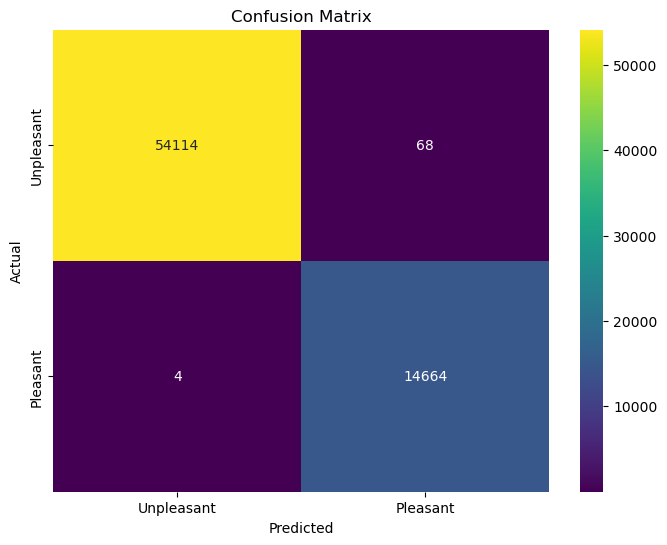

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', 
            xticklabels=['Unpleasant', 'Pleasant'],
            yticklabels=['Unpleasant', 'Pleasant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Convolutional & Recurrent Neural Networks

CNNs and RNNs are designed to identify spatial and temporal patterns respectively.

Here we use each type of model to predict if a future date's weather will be pleasant based on the preceding 6 days' weather observations.

In [4]:
def create_weather_sequences_with_metadata(df, date_col='DATE', location_col='city', 
                                         feature_cols=None, sequence_length=6):
    """Convert tabular DataFrame to sequences for analysis with metadata tracking."""
    
    # Get feature columns
    if feature_cols is None:
        feature_cols = df.columns.drop([date_col, location_col, 'MONTH', 'pleasant_weather'])
    
    # Sort by location and date
    df_sorted = df.sort_values([location_col, date_col])
    
    # Create sequences for each location
    sequences = []
    targets = []
    metadata = []  # Track city and date for each sequence
    
    for location in df_sorted[location_col].unique():
        location_data = df_sorted[df_sorted[location_col] == location]
        features = location_data[feature_cols].values
        
        # Ensure target is AFTER the sequence
        for i in range(len(features) - sequence_length):
            sequences.append(features[i:i+sequence_length])  # t-6 to t-1
            targets.append(location_data.iloc[i+sequence_length]['pleasant_weather'])  # t
            metadata.append({
                'city': location,
                'date': location_data.iloc[i+sequence_length][date_col],
                'sequence_idx': len(sequences) - 1  # Index in the sequences array
            })
    
    return np.array(sequences), np.array(targets), metadata

In [5]:
# Create sequences with metadata
sequences, targets, metadata = create_weather_sequences_with_metadata(df, sequence_length=6)

In [6]:
# Create train/test split and preserve metadata
X_train, X_test, y_train, y_test, train_meta, test_meta = train_test_split(
    sequences, targets, metadata, 
    test_size=0.2, 
    random_state=42,
    stratify=targets
)

In [8]:
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN

##### RNN is the most sensible model for time-series prediction

In [8]:
# RNN
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(7,9)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

2025-07-16 13:10:24.329513: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/scruffy/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# RNN multilayer
model = Sequential([
    LSTM(128, return_sequences=True,input_shape=(7, 9)),
    Dropout(0.5),
    BatchNormalization(),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    BatchNormalization(),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

2025-07-18 18:45:40.020843: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/scruffy/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
# CNN
model = Sequential()
model.add(Conv1D(64, kernel_size=2, activation='relu', input_shape=(7,9)))
model.add(Conv1D(32, 2, activation='relu')),
model.add(MaxPooling1D())
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

2025-07-09 14:25:56.563435: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [33]:
model = Sequential([
    Conv1D(128, 3, activation='relu', input_shape=(7,9), padding='same'),
    Dropout(0.3),
    Conv1D(64, 3, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling1D(),  # Alternative to GlobalMaxPooling
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [23]:
# Train CNN
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 6, 64)          │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 5, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,409 (21.13 KB)

 Trainable params: 5,409 (21.13 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train CNN
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_26 (Conv1D)              │ (None, 7, 128)         │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 7, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,593 (119.50 KB)

 Trainable params: 30,465 (119.00 KB)

 Non-trainable params: 128 (512.00 B)

In [9]:
# Train RNN
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train RNN multi-layer
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 128)         │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,281 (520.63 KB)

 Trainable params: 132,897 (519.13 KB)

 Non-trainable params: 384 (1.50 KB)

In [24]:
# Fit CNN
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20)

Epoch 1/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.8574 - loss: 0.2915 - val_accuracy: 0.8667 - val_loss: 0.2704
Epoch 2/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8703 - loss: 0.2652 - val_accuracy: 0.8710 - val_loss: 0.2617
Epoch 3/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - accuracy: 0.8711 - loss: 0.2634 - val_accuracy: 0.8702 - val_loss: 0.2635
Epoch 4/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.8725 - loss: 0.2606 - val_accuracy: 0.8710 - val_loss: 0.2628
Epoch 5/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.8733 - loss: 0.2593 - val_accuracy: 0.8705 - val_loss: 0.2610
Epoch 6/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.8735 - loss: 0.2585 - val_accuracy: 0.8689 - val_loss: 0.2661
Epoch 7/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.8737 - loss: 0.2586 - val_accuracy: 0.8726 - val_loss: 0.2598
Epoch 8/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.8747 - loss: 0

In [35]:
# Fit CNN
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5)

Epoch 1/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.8568 - loss: 0.2895 - val_accuracy: 0.8722 - val_loss: 0.2636
Epoch 2/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - accuracy: 0.8688 - loss: 0.2674 - val_accuracy: 0.8726 - val_loss: 0.2575
Epoch 3/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - accuracy: 0.8692 - loss: 0.2666 - val_accuracy: 0.8736 - val_loss: 0.2571
Epoch 4/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - accuracy: 0.8705 - loss: 0.2632 - val_accuracy: 0.8727 - val_loss: 0.2592
Epoch 5/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 65s 8ms/step - accuracy: 0.8710 - loss: 0.2628 - val_accuracy: 0.8745 - val_loss: 0.2551


In [9]:
# Fit CNN
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5)

Epoch 1/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.8575 - loss: 0.2900 - val_accuracy: 0.8686 - val_loss: 0.2691
Epoch 2/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - accuracy: 0.8700 - loss: 0.2671 - val_accuracy: 0.8691 - val_loss: 0.2696
Epoch 3/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.8726 - loss: 0.2619 - val_accuracy: 0.8708 - val_loss: 0.2630
Epoch 4/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - accuracy: 0.8712 - loss: 0.2621 - val_accuracy: 0.8715 - val_loss: 0.2636
Epoch 5/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 60s 7ms/step - accuracy: 0.8729 - loss: 0.2608 - val_accuracy: 0.8722 - val_loss: 0.2629


In [47]:
# Fit RNN
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20)

Epoch 1/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 64s 7ms/step - accuracy: 0.8518 - loss: 0.3019 - val_accuracy: 0.8746 - val_loss: 0.2585
Epoch 2/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 99s 11ms/step - accuracy: 0.8680 - loss: 0.2687 - val_accuracy: 0.8763 - val_loss: 0.2555
Epoch 3/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 75s 9ms/step - accuracy: 0.8717 - loss: 0.2642 - val_accuracy: 0.8759 - val_loss: 0.2541
Epoch 4/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 72s 8ms/step - accuracy: 0.8703 - loss: 0.2634 - val_accuracy: 0.8778 - val_loss: 0.2533
Epoch 5/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 78s 9ms/step - accuracy: 0.8722 - loss: 0.2616 - val_accuracy: 0.8775 - val_loss: 0.2525
Epoch 6/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 89s 10ms/step - accuracy: 0.8722 - loss: 0.2617 - val_accuracy: 0.8774 - val_loss: 0.2530
Epoch 7/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 68s 8ms/step - accuracy: 0.8729 - loss: 0.2607 - val_accuracy: 0.8779 - val_loss: 0.2528
Epoch 8/20
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 69s 8ms/step - accuracy: 0.8728 - loss:

In [10]:
# Fit RNN
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5)

Epoch 1/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 93s 10ms/step - accuracy: 0.8541 - loss: 0.3005 - val_accuracy: 0.8718 - val_loss: 0.2604
Epoch 2/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 76s 9ms/step - accuracy: 0.8688 - loss: 0.2670 - val_accuracy: 0.8741 - val_loss: 0.2586
Epoch 3/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 75s 9ms/step - accuracy: 0.8692 - loss: 0.2661 - val_accuracy: 0.8750 - val_loss: 0.2560
Epoch 4/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 101s 12ms/step - accuracy: 0.8716 - loss: 0.2637 - val_accuracy: 0.8754 - val_loss: 0.2553
Epoch 5/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 78s 9ms/step - accuracy: 0.8715 - loss: 0.2617 - val_accuracy: 0.8764 - val_loss: 0.2542


In [11]:
# Fit RNN multilayer
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5)

Epoch 1/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 274s 30ms/step - accuracy: 0.8509 - loss: 0.3009 - val_accuracy: 0.8725 - val_loss: 0.2652
Epoch 2/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 294s 34ms/step - accuracy: 0.8681 - loss: 0.2688 - val_accuracy: 0.8748 - val_loss: 0.2571
Epoch 3/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 268s 31ms/step - accuracy: 0.8713 - loss: 0.2636 - val_accuracy: 0.8731 - val_loss: 0.2576
Epoch 4/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 317s 31ms/step - accuracy: 0.8717 - loss: 0.2625 - val_accuracy: 0.8752 - val_loss: 0.2559
Epoch 5/5
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 262s 30ms/step - accuracy: 0.8732 - loss: 0.2604 - val_accuracy: 0.8753 - val_loss: 0.2547


## Evaluation

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

In [ ]:
# Comprehensive evaluation function
def evaluate_model(model, X_test, y_test):
    # Predictions and probabilities
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    y_probs = model.predict(X_test)
    
    # Basic metrics
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
    
    return {
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred, output_dict=True),
        'auc_score': auc_score
    }

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 1s 515us/step
2151/2151 ━━━━━━━━━━━━━━━━━━━━ 1s 499us/step
Confusion Matrix:
[[49928  4079]
 [ 4723 10102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     54007
           1       0.71      0.68      0.70     14825

    accuracy                           0.87     68832
   macro avg       0.81      0.80      0.81     68832
weighted avg       0.87      0.87      0.87     68832



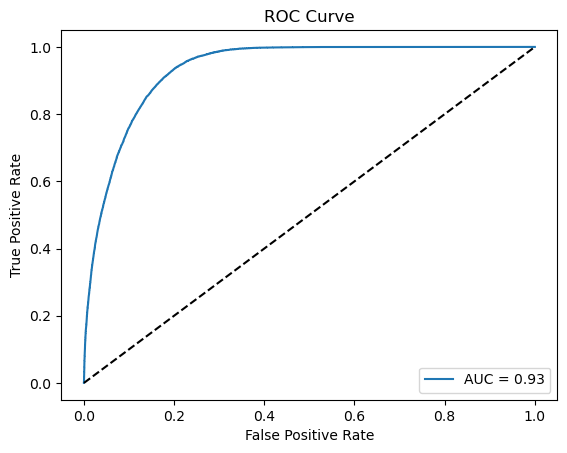

In [33]:
# Evaluate CNN
results = evaluate_model(model, X_test, y_test)

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2151/2151 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Confusion Matrix:
[[50396  3860]
 [ 4614  9959]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     54256
           1       0.72      0.68      0.70     14573

    accuracy                           0.88     68829
   macro avg       0.82      0.81      0.81     68829
weighted avg       0.87      0.88      0.88     68829



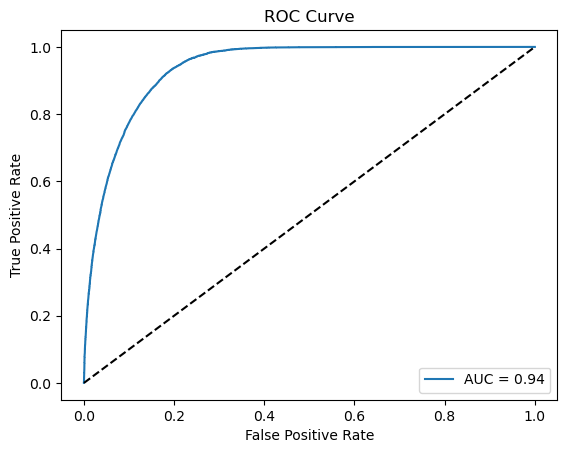

In [48]:
# Evaluate RNN
results = evaluate_model(model, X_test, y_test)

In [31]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Convert metadata to DataFrame for easier manipulation
test_df = pd.DataFrame(test_meta)
test_df['y_true'] = y_test
test_df['y_pred'] = y_pred
    
# Get unique cities and sort them
cities = sorted(test_df['city'].unique())
    
# Create confusion matrices
conf_matrices = []
    
for idx, city in enumerate(cities):
        
    # Filter data for current city
    city_data = test_df[test_df['city'] == city]
    y_true_city = city_data['y_true'].values
    y_pred_city = city_data['y_pred'].values

    # Confusion matrix heatmap
    cm = confusion_matrix(y_true_city, y_pred_city, labels=[0, 1])
    conf_matrices.append((city, cm))

# Display
print("Array of Confusion Matrices by City:")
for i, (city, cm) in enumerate(conf_matrices):
    print(f"\nCity: {city}")
    print(cm)
    print(classification_report(y_test, y_pred, 
                          target_names=['Unpleasant', 'Pleasant']))

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Array of Confusion Matrices by City:

City: BASEL
[[3185  376]
 [ 346  747]]

City: BELGRADE
[[2536  438]
 [ 403 1164]]

City: BUDAPEST
[[2621  399]
 [ 345 1091]]

City: DEBILT
[[3457  189]
 [ 370  573]]

City: DUSSELDORF
[[3247  315]
 [ 356  660]]

City: HEATHROW
[[3431  252]
 [ 347  627]]

City: KASSEL
[[3652  228]
 [ 268  460]]

City: LJUBLJANA
[[2981  340]
 [ 424  853]]

City: MAASTRICHT
[[3485  235]
 [ 330  611]]

City: MADRID
[[2191  326]
 [ 280 1882]]

City: MUNCHENB
[[3170  346]
 [ 402  572]]

City: OSLO
[[3737  166]
 [ 284  390]]

City: SONNBLICK
[[4624    0]
 [   0    0]]

City: STOCKHOLM
[[3559  160]
 [ 394  403]]

City: VALENTIA
[[4312   71]
 [ 119  102]]


In [51]:
# Create classification reports
reports = []
    
for idx, city in enumerate(cities):
        
    # Filter data for current city
    city_data = test_df[test_df['city'] == city]
    y_true_city = city_data['y_true'].values
    y_pred_city = city_data['y_pred'].values

    # Classification reports
    cr = classification_report(y_true_city, y_pred_city, labels=[0,1], target_names=['Unpleasant', 'Pleasant'], zero_division=1.0)
    reports.append((city, cr))

# Display
print("Array of Classification Reports by City:")
for i, (city, cr) in enumerate(reports):
    print(f"\nCity: {city}")
    print(cr)

Array of Classification Reports by City:

City: BASEL
              precision    recall  f1-score   support

  Unpleasant       0.90      0.89      0.90      3561
    Pleasant       0.67      0.68      0.67      1093

    accuracy                           0.84      4654
   macro avg       0.78      0.79      0.79      4654
weighted avg       0.85      0.84      0.85      4654


City: BELGRADE
              precision    recall  f1-score   support

  Unpleasant       0.86      0.85      0.86      2974
    Pleasant       0.73      0.74      0.73      1567

    accuracy                           0.81      4541
   macro avg       0.79      0.80      0.80      4541
weighted avg       0.82      0.81      0.82      4541


City: BUDAPEST
              precision    recall  f1-score   support

  Unpleasant       0.88      0.87      0.88      3020
    Pleasant       0.73      0.76      0.75      1436

    accuracy                           0.83      4456
   macro avg       0.81      0.81      0.8

In [13]:
def plot_city_performance_corrected(y_test, y_pred, test_metadata):
    """Plot confusion matrices for each city using test metadata."""
    
    # Convert metadata to DataFrame for easier manipulation
    test_df = pd.DataFrame(test_metadata)
    test_df['y_true'] = y_test
    test_df['y_pred'] = y_pred
    
    # Get unique cities and sort them
    cities = sorted(test_df['city'].unique())
    
    # Determine grid size - maximum 5 columns
    n_cities = len(cities)
    n_cols = min(5, n_cities)
    n_rows = int(np.ceil(n_cities / n_cols))
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
    
    # Flatten axes for easier iteration
    flat_axes = axes.flatten()
    
    for idx, city in enumerate(cities):
        # Get axes
        matrix_ax = flat_axes[idx]
        
        # Filter data for current city
        city_data = test_df[test_df['city'] == city]
        y_true_city = city_data['y_true'].values
        y_pred_city = city_data['y_pred'].values

        # Confusion matrix heatmap
        cm = confusion_matrix(y_true_city, y_pred_city, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Unpleasant', 'Pleasant'],
                    yticklabels=['Unpleasant', 'Pleasant'],
                    ax=matrix_ax)
        matrix_ax.set_title(f'{city} - Confusion Matrix (n={len(y_true_city)})')
        matrix_ax.set_xlabel('Predicted')
        matrix_ax.set_ylabel('Actual')
    
    # Hide any empty subplots
    for j in range(n_cities, len(flat_axes)):
        flat_axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


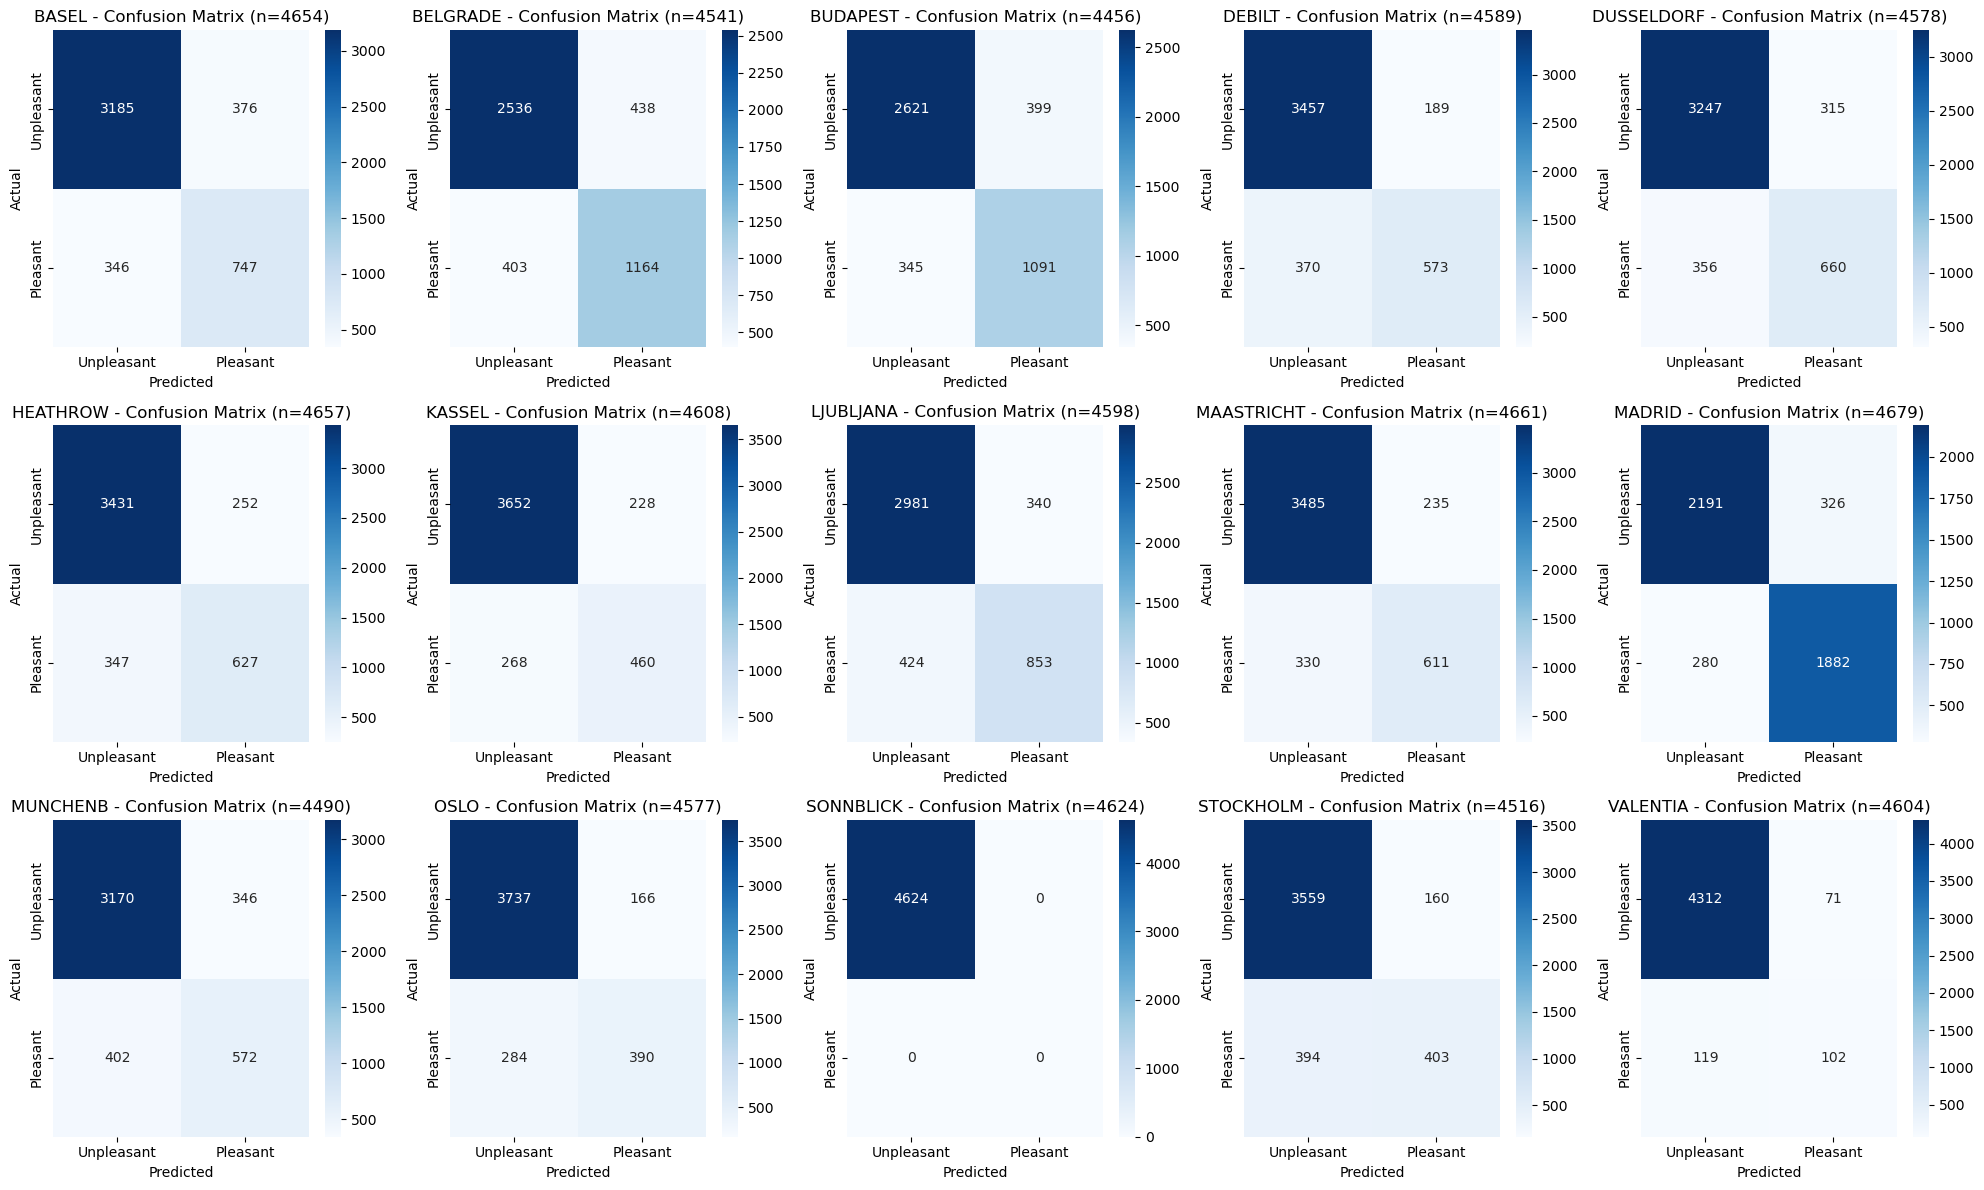

In [18]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
plot_city_performance_corrected(y_test, y_pred, test_meta)

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step


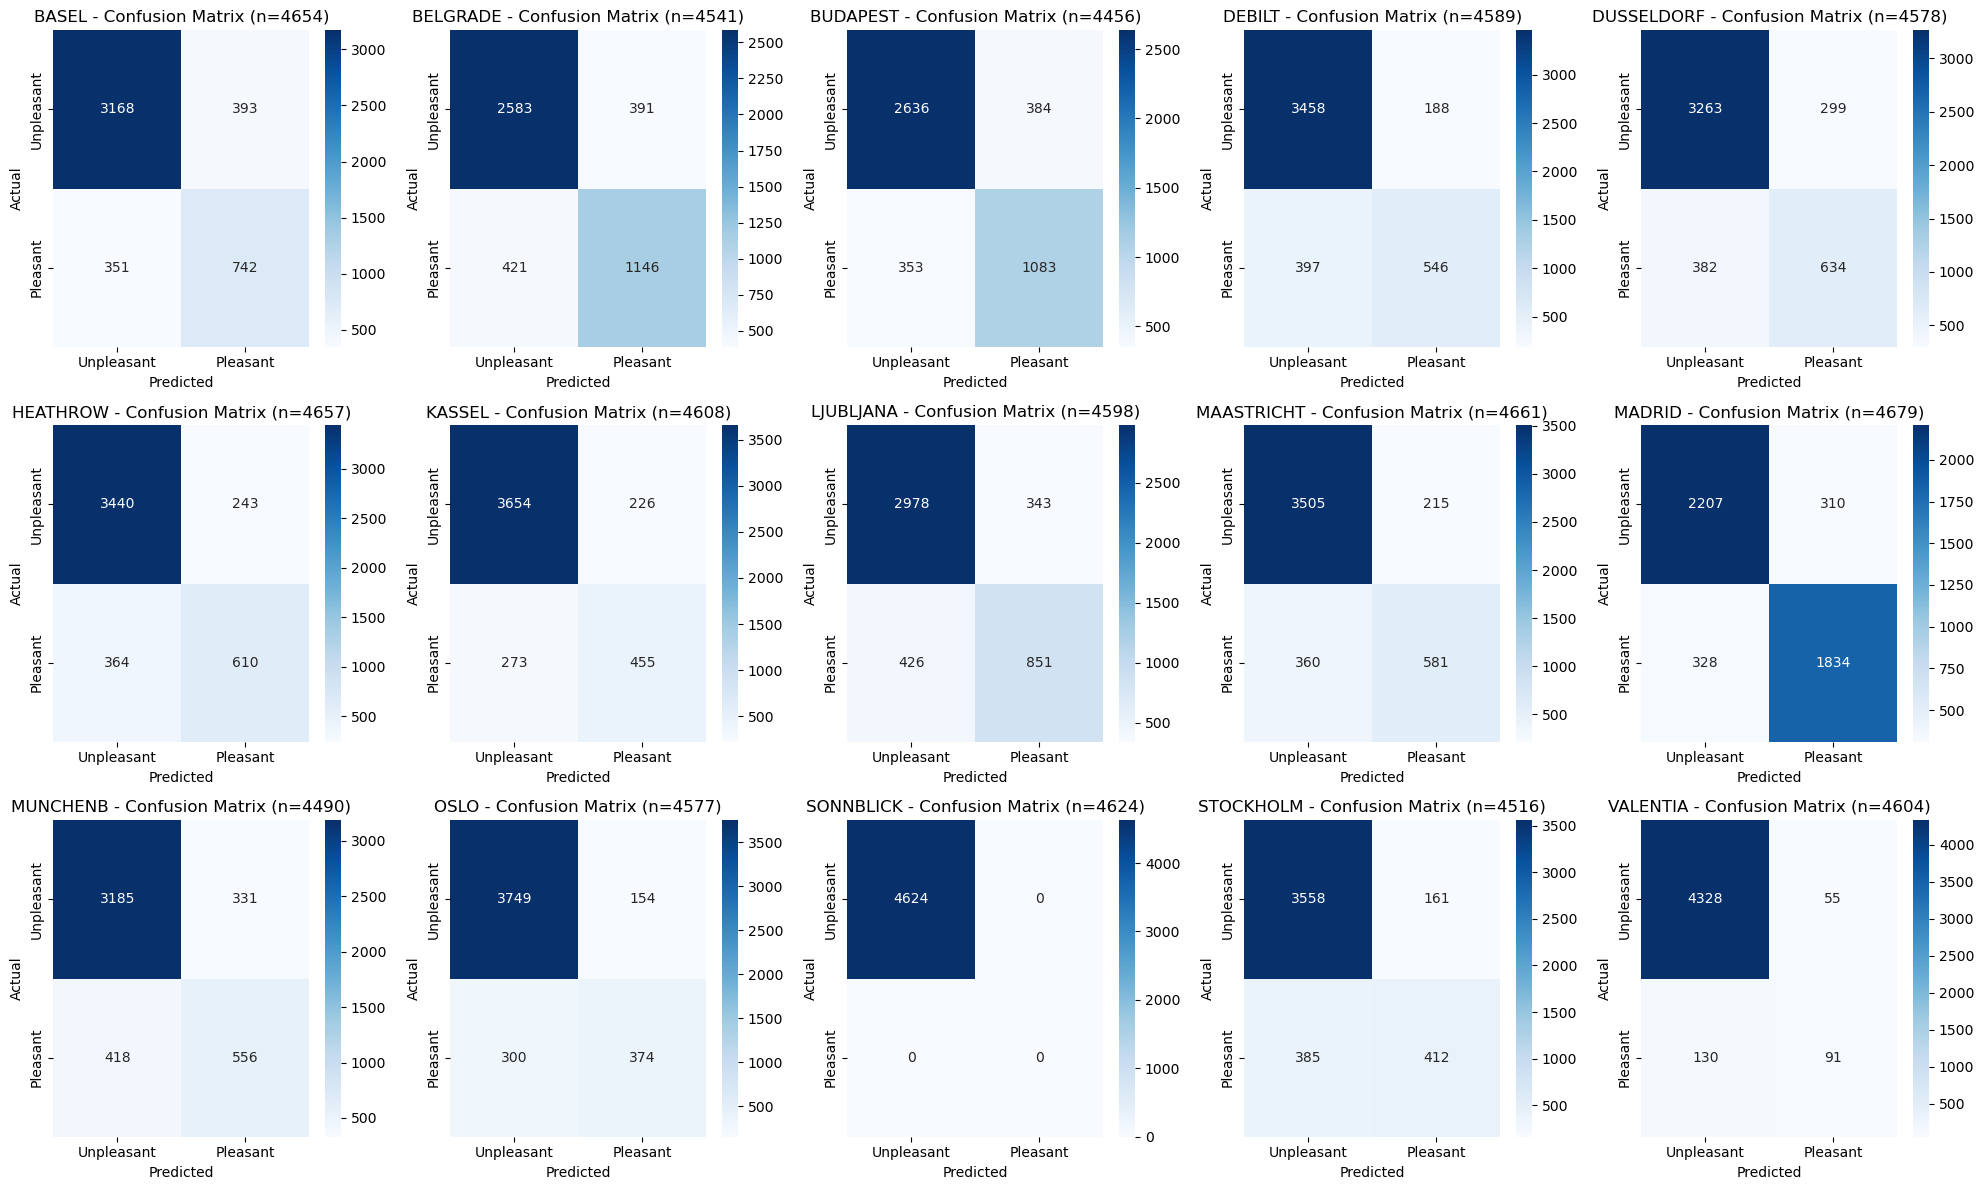

In [14]:
# RNN Multilayer
y_pred = (model.predict(X_test) > 0.5).astype("int32")
plot_city_performance_corrected(y_test, y_pred, test_meta)

In [19]:
def compute_feature_importance(model, X_sample):
    X_tensor = tf.convert_to_tensor(X_sample, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model(X_tensor[np.newaxis, ...]) # Add batch dimension
    grads = tape.gradient(predictions, X_tensor)
    return tf.abs(grads).numpy()  # Absolute gradients (7,9) shape

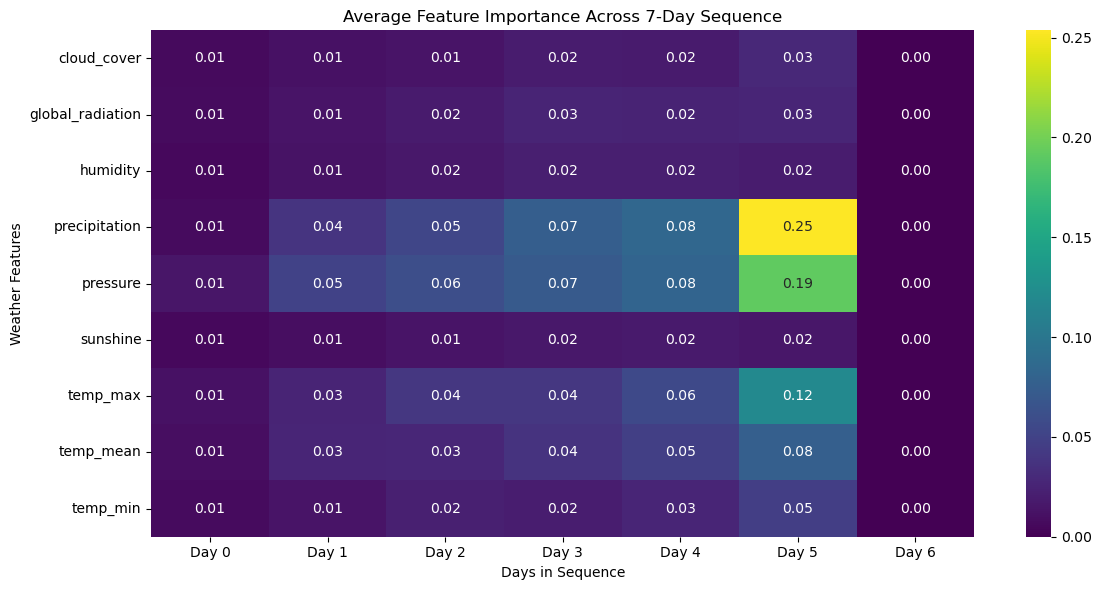

In [67]:
# CNN 1
# Compute importance for multiple samples
n_samples = 1000  # Adjust based on your dataset size
importance_scores = np.zeros_like(X_test[0])  # Initialize (7,9) array

for sample in X_test[:n_samples]:
    importance_scores += compute_feature_importance(model, sample)
    
avg_importance = importance_scores / n_samples

# Plot heatmap
plt.figure(figsize=(12, 6))
feature_cols = df.columns.drop(['DATE','city','MONTH','pleasant_weather']).tolist()

sns.heatmap(
    avg_importance.T,  # Transpose to (features, days)
    cmap='viridis',
    annot=True,
    fmt=".2f",
    xticklabels=[f"Day {i}" for i in range(7)],
    yticklabels=feature_cols
)
plt.title("Average Feature Importance Across 7-Day Sequence")
plt.xlabel("Days in Sequence")
plt.ylabel("Weather Features")
plt.tight_layout()
plt.show()

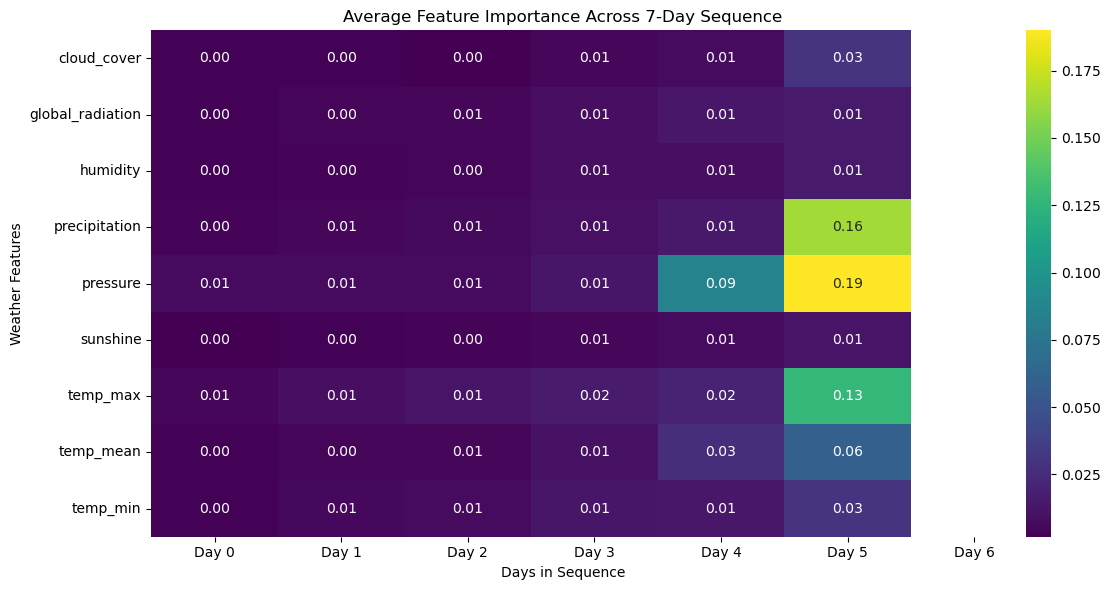

In [38]:
# CNN 2
# Compute importance for multiple samples
n_samples = 1000  # Adjust based on your dataset size
importance_scores = np.zeros_like(X_test[0])  # Initialize (7,9) array

for sample in X_test[:n_samples]:
    importance_scores += compute_feature_importance(model, sample)
    
avg_importance = importance_scores / n_samples

# Plot heatmap
plt.figure(figsize=(12, 6))
feature_cols = df.columns.drop(['DATE','city','MONTH','pleasant_weather']).tolist()

sns.heatmap(
    avg_importance.T,  # Transpose to (features, days)
    cmap='viridis',
    annot=True,
    fmt=".2f",
    xticklabels=[f"Day {i}" for i in range(7)],
    yticklabels=feature_cols
)
plt.title("Average Feature Importance Across 7-Day Sequence")
plt.xlabel("Days in Sequence")
plt.ylabel("Weather Features")
plt.tight_layout()
plt.show()

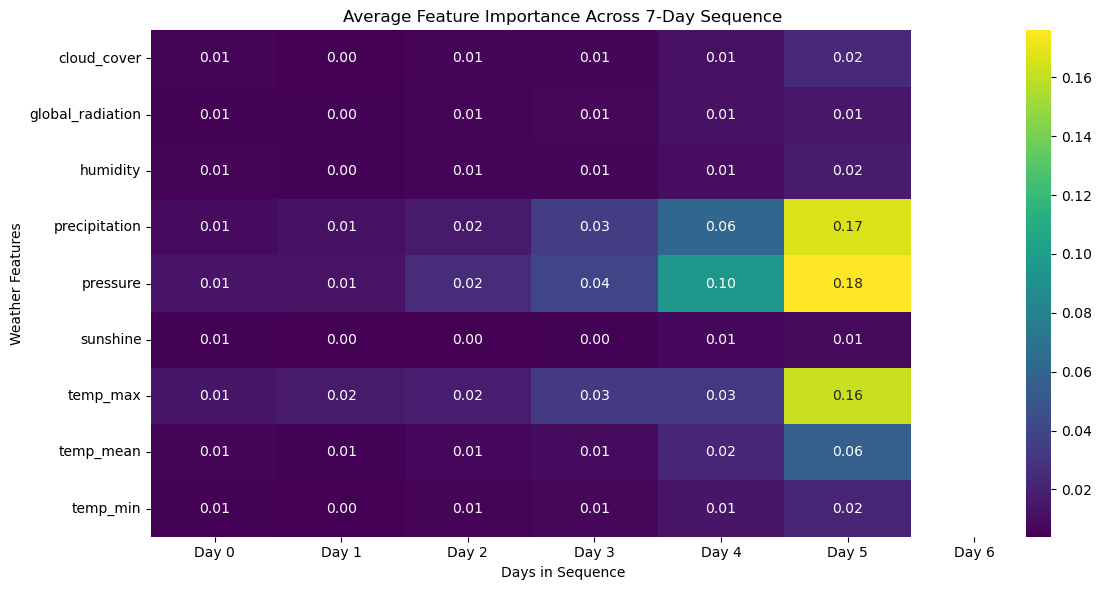

In [34]:
# RNN
# Compute importance for multiple samples
n_samples = 1000  # Adjust based on your dataset size
importance_scores = np.zeros_like(X_test[0])  # Initialize (7,9) array

for sample in X_test[:n_samples]:
    importance_scores += compute_feature_importance(model, sample)
    
avg_importance = importance_scores / n_samples

# Plot heatmap
plt.figure(figsize=(12, 6))
feature_cols = df.columns.drop(['DATE','city','MONTH','pleasant_weather']).tolist()

sns.heatmap(
    avg_importance.T,  # Transpose to (features, days)
    cmap='viridis',
    annot=True,
    fmt=".2f",
    xticklabels=[f"Day {i}" for i in range(7)],
    yticklabels=feature_cols
)
plt.title("Average Feature Importance Across 7-Day Sequence")
plt.xlabel("Days in Sequence")
plt.ylabel("Weather Features")
plt.tight_layout()
plt.show()

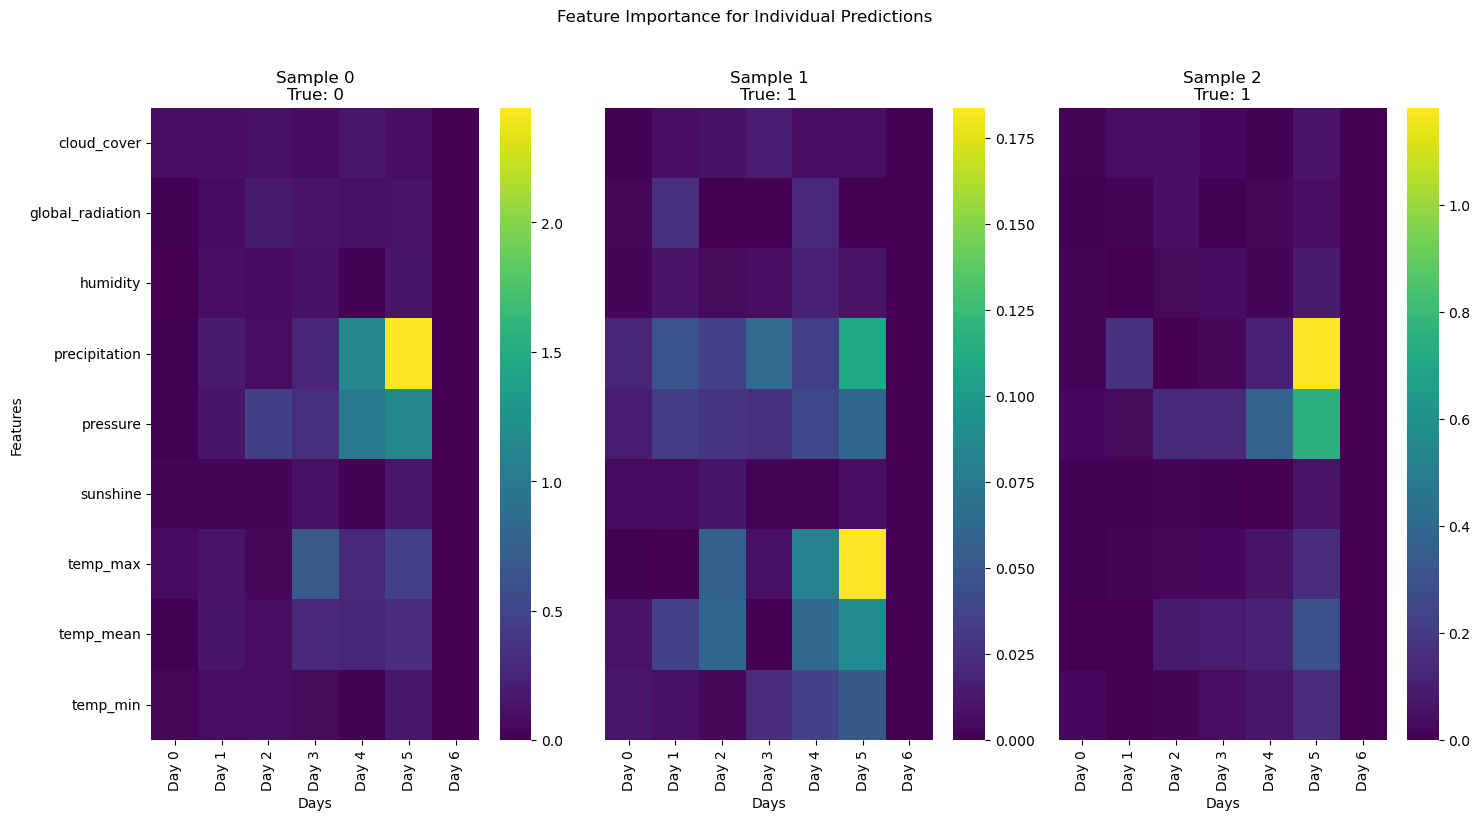

In [62]:
# CNN 1
# Plot importance for 3 different samples
samples_to_plot = [0, 1, 2]  # First 3 test samples

plt.figure(figsize=(10, 8))
for i, sample_idx in enumerate(samples_to_plot, 1):
    importance = compute_feature_importance(model, X_test[sample_idx])
    
    plt.subplot(1, 3, i)
    sns.heatmap(
        importance.T,
        cmap='viridis',
        vmin=0,
        vmax=np.max(importance),  # Consistent color scale
        xticklabels=[f"Day {i}" for i in range(7)],
        yticklabels=feature_cols if i == 1 else []
    )
    plt.title(f"Sample {sample_idx}\nTrue: {y_test[sample_idx]}")
    if i == 1:
        plt.ylabel("Features")
    plt.xlabel("Days")

plt.suptitle("Feature Importance for Individual Predictions", y=1.02)
plt.tight_layout()
plt.show()

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 2s 760us/step


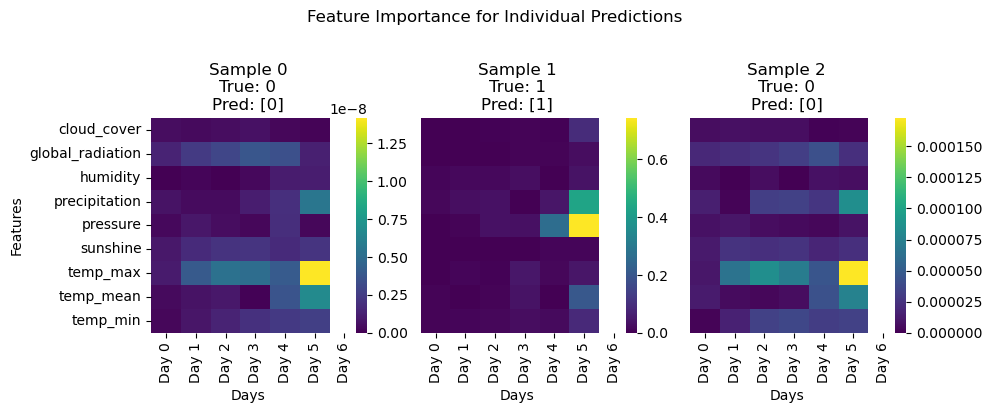

In [39]:
# CNN 2
# Plot importance for 3 different samples
samples_to_plot = [0, 1, 2]  # First 3 test samples
y_pred = (model.predict(X_test) > 0.5).astype("int32")

plt.figure(figsize=(10, 4))
for i, sample_idx in enumerate(samples_to_plot, 1):
    importance = compute_feature_importance(model, X_test[sample_idx])
    
    plt.subplot(1, 3, i)
    sns.heatmap(
        importance.T,
        cmap='viridis',
        vmin=0,
        vmax=np.max(importance),  # Consistent color scale
        xticklabels=[f"Day {i}" for i in range(7)],
        yticklabels=feature_cols if i == 1 else []
    )
    plt.title(f"Sample {sample_idx}\nTrue: {y_test[sample_idx]}\nPred: {y_pred[sample_idx]}")
    if i == 1:
        plt.ylabel("Features")
    plt.xlabel("Days")

plt.suptitle("Feature Importance for Individual Predictions", y=1.02)
plt.tight_layout()
plt.show()